In [1]:
import pysam as os
import json 
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import collections
import re
import seaborn as sns
import pysam

In [2]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
def get_attr(attr_string, key):
    for field in attr_string.split(";"):
        if field.startswith(key + "="):
            return field.split("=")[1]
    return None

In [5]:
from __future__ import annotations
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
import pandas as pd
import numpy as np
import re

@dataclass(frozen=True)
class _Feat:
    idx: int
    contig: str
    start: int
    end: int
    strand: str
    name: str
    biotype: str


def gene_family_root(name: str) -> str:
    """Leading-letter family root (e.g., CDY1->CDY, RBMY1A1->RBMY, XKRYP7->XKRY)."""
    if not name or name == ".":
        return "."
    name = str(name).upper()

    m = re.match(r"([A-Z]+)", name)
    root = m.group(1) if m else name

    if root.endswith("P") and re.fullmatch(root + r"\d+.*", name):
        root = root[:-1]

    return root


def gene_names_similar(name1: str, name2: str, *, min_root_len: int = 2) -> bool:
    """
    Similar if:
      1) exact match (case-insensitive), OR
      2) same leading-letter root (original behavior), OR
      3) special-case: XKRY <-> XKRYP# (pseudogene-like naming)
      4) special-case: if either name looks like an Ensembl gene ID starting with ENSG0,
         treat as a wildcard that matches any other non-empty, non-dot gene name
    """
    if not name1 or not name2:
        return False
    if name1 == "." or name2 == ".":
        return False

    n1 = str(name1).upper()
    n2 = str(name2).upper()

    if n1.startswith("ENSG0") or n2.startswith("ENSG0"):
        return True

    if n1 == n2:
        return True

    r1 = gene_family_root(n1)
    r2 = gene_family_root(n2)
    if (r1 == r2) and (len(r1) >= min_root_len):
        return True

    def _xkry_base(n: str) -> str:
        return re.sub(r"^XKRYP\d+$", "XKRY", n)

    b1 = _xkry_base(n1)
    b2 = _xkry_base(n2)
    if b1 == b2 and b1 != ".":
        return True

    return False

def default_sample_from_contig(contig: str) -> str:
    """
    Best-effort sample ID extraction from contig names like:
      HG02011_chrY, HG02011_chrY_random, NA18612_chrY_hap2, etc.
    Returns the prefix before the first underscore. If no underscore, returns contig.
    """
    contig = str(contig)
    return contig.split("_", 1)[0] if "_" in contig else contig


def _to_feats(
    df: pd.DataFrame,
    *,
    contig_col=0,
    start_col=3,
    end_col=4,
    strand_col=6,
    name_col: str,
    biotype_col: str,
    require_type_gene: bool = True,
    type_col=2,
) -> List[_Feat]:
    work = df.copy()

    if require_type_gene and type_col in work.columns:
        work = work[work[type_col].astype(str) == "gene"].copy()

    work[contig_col] = work[contig_col].astype(str)
    work[start_col] = pd.to_numeric(work[start_col], errors="coerce").astype("Int64")
    work[end_col]   = pd.to_numeric(work[end_col], errors="coerce").astype("Int64")
    work[strand_col] = work[strand_col].astype(str)
    work = work.dropna(subset=[start_col, end_col]).copy()

    s = work[start_col].astype(int).to_numpy()
    e = work[end_col].astype(int).to_numpy()
    work[start_col] = np.minimum(s, e)
    work[end_col]   = np.maximum(s, e)

    if name_col not in work.columns:
        raise KeyError(f"name_col '{name_col}' not found in dataframe columns.")
    work[name_col] = work[name_col].fillna("").astype(str)

    if biotype_col not in work.columns:
        raise KeyError(f"biotype_col '{biotype_col}' not found in dataframe columns.")
    work[biotype_col] = work[biotype_col].fillna("").astype(str)
    work[biotype_col] = work[biotype_col].replace("", ".")

    feats: List[_Feat] = []
    for idx, row in work.iterrows():
        feats.append(
            _Feat(
                idx=int(idx) if str(idx).isdigit() else hash(idx),
                contig=str(row[contig_col]),
                start=int(row[start_col]),
                end=int(row[end_col]),
                strand=str(row[strand_col]) if str(row[strand_col]) in {"+", "-", "."} else ".",
                name=str(row[name_col]) if str(row[name_col]) else ".",
                biotype=str(row[biotype_col]) if str(row[biotype_col]) else ".",
            )
        )

    feats.sort(key=lambda f: (f.contig, f.start, f.end, f.idx))
    return feats


def _overlap_len(a: _Feat, b: _Feat) -> int:
    lo = max(a.start, b.start)
    hi = min(a.end, b.end)
    return max(0, hi - lo + 1)


def compare_gene_annotations_to_bed_v5(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    *,
    contig_col=0,
    start_col=3,
    end_col=4,
    strand_col=6,
    df1_name_col: str = "GeneName",
    df2_name_col: str = "GeneName2",
    df1_biotype_col: str = "GeneBiotype",
    df2_biotype_col: str = "GeneBiotype",
    require_type_gene: bool = True,
    type_col=2,

    min_reciprocal_overlap: float = 0.50,
    min_overlap_bp: int = 1,
    enforce_same_strand: bool = True,

    require_gene_similarity_for_matching: bool = True,
    min_root_len: int = 2,

    anchor_start_or_end_match: bool = True,

    sample_from_contig: Optional[callable] = None,
) -> pd.DataFrame:
    """
    Contig-aware comparison:
      - matches are only considered within the same contig string
      - output includes BOTH 'sample' (derived) and 'contig' (explicit)

    Output columns (adds biotype + contig/sample):
      sample, contig, start, end, strand,
      gene_name_df1, gene_name_df2, gene_name,
      biotype_df1, biotype_df2, biotype,
      df1, df2,
      COORDINATES_DIFFER, df1_start, df1_end, df2_start, df2_end,
      df1_coords, df2_coords,
      MATCH_REASON, GENE_NAME_SIMILAR, GENE_ROOT_1, GENE_ROOT_2
    """

    if sample_from_contig is None:
        sample_from_contig = default_sample_from_contig

    feats1 = _to_feats(
        df1,
        contig_col=contig_col, start_col=start_col, end_col=end_col,
        strand_col=strand_col, name_col=df1_name_col, biotype_col=df1_biotype_col,
        require_type_gene=require_type_gene, type_col=type_col
    )
    feats2 = _to_feats(
        df2,
        contig_col=contig_col, start_col=start_col, end_col=end_col,
        strand_col=strand_col, name_col=df2_name_col, biotype_col=df2_biotype_col,
        require_type_gene=require_type_gene, type_col=type_col
    )

    by_contig1: Dict[str, List[_Feat]] = {}
    by_contig2: Dict[str, List[_Feat]] = {}
    for f in feats1:
        by_contig1.setdefault(f.contig, []).append(f)
    for f in feats2:
        by_contig2.setdefault(f.contig, []).append(f)

    id1 = {f.idx: f for f in feats1}
    id2 = {f.idx: f for f in feats2}

    candidates: List[Tuple[float, float, int, int, int, str]] = []

    for contig in sorted(set(by_contig1) | set(by_contig2)):
        A = by_contig1.get(contig, [])
        B = by_contig2.get(contig, [])
        if not A or not B:
            continue

        j = 0
        for a in A:
            while j < len(B) and B[j].end < a.start:
                j += 1
            k = j
            while k < len(B) and B[k].start <= a.end:
                b = B[k]

                if enforce_same_strand and (a.strand in {"+", "-"} and b.strand in {"+", "-"}) and (a.strand != b.strand):
                    k += 1
                    continue

                ov = _overlap_len(a, b)
                if ov < min_overlap_bp:
                    k += 1
                    continue

                similar = gene_names_similar(a.name, b.name, min_root_len=min_root_len)
                if require_gene_similarity_for_matching and not similar:
                    k += 1
                    continue

                len_a = a.end - a.start + 1
                len_b = b.end - b.start + 1
                recip = min(ov / len_a, ov / len_b)

                if recip >= min_reciprocal_overlap:
                    score = 2.0 + recip + (ov / 1e12)
                    candidates.append((score, recip, ov, a.idx, b.idx, "RECIP_OVERLAP"))

                if anchor_start_or_end_match and (a.start == b.start or a.end == b.end):
                    score = 3.0 + recip + (ov / 1e12)
                    candidates.append((score, recip, ov, a.idx, b.idx, "ANCHOR_START_OR_END"))

                k += 1

    candidates.sort(key=lambda x: x[0], reverse=True)

    matched1: Dict[int, int] = {}
    matched2: Dict[int, int] = {}
    match_reason: Dict[Tuple[int, int], str] = {}

    for score, recip, ov, a_idx, b_idx, reason in candidates:
        if a_idx in matched1 or b_idx in matched2:
            continue
        matched1[a_idx] = b_idx
        matched2[b_idx] = a_idx
        match_reason[(a_idx, b_idx)] = reason

    rows: List[Dict] = []

    def _base(sample: str, contig: str, start: int, end: int, strand: str) -> Dict:
        return {"sample": sample, "contig": contig, "start": start, "end": end, "strand": strand}

    for a_idx, b_idx in matched1.items():
        a = id1[a_idx]
        b = id2[b_idx]

        contig = a.contig
        sample = sample_from_contig(contig)

        out_start = min(a.start, b.start)
        out_end = max(a.end, b.end)

        strand = a.strand if a.strand == b.strand else "."
        coords_differ = "YES" if (a.start != b.start or a.end != b.end) else "NO"

        similar = gene_names_similar(a.name, b.name, min_root_len=min_root_len)
        r1 = gene_family_root(a.name)
        r2 = gene_family_root(b.name)

        gene_name_df1 = a.name
        gene_name_df2 = b.name
        gene_name = gene_name_df1 if gene_name_df1.upper() == gene_name_df2.upper() else f"{gene_name_df1}|{gene_name_df2}"

        biotype_df1 = a.biotype
        biotype_df2 = b.biotype
        biotype = biotype_df1 if biotype_df1 == biotype_df2 else f"{biotype_df1}|{biotype_df2}"

        row = _base(sample, contig, out_start, out_end, strand)
        row.update({
            "gene_name_df1": gene_name_df1,
            "gene_name_df2": gene_name_df2,
            "gene_name": gene_name,

            "biotype_df1": biotype_df1,
            "biotype_df2": biotype_df2,
            "biotype": biotype,

            "df1": "CALLED",
            "df2": "CALLED",

            "COORDINATES_DIFFER": coords_differ,
            "df1_start": a.start,
            "df1_end": a.end,
            "df2_start": b.start,
            "df2_end": b.end,
            "df1_coords": f"{a.contig}:{a.start}-{a.end}({a.strand})",
            "df2_coords": f"{b.contig}:{b.start}-{b.end}({b.strand})",

            "MATCH_REASON": match_reason.get((a_idx, b_idx), "."),
            "GENE_NAME_SIMILAR": "YES" if similar else "NO",
            "GENE_ROOT_1": r1,
            "GENE_ROOT_2": r2,
        })
        rows.append(row)

    for a in feats1:
        if a.idx in matched1:
            continue

        contig = a.contig
        sample = sample_from_contig(contig)

        row = _base(sample, contig, a.start, a.end, a.strand)
        row.update({
            "gene_name_df1": a.name,
            "gene_name_df2": ".",
            "gene_name": a.name,

            "biotype_df1": a.biotype,
            "biotype_df2": ".",
            "biotype": a.biotype,

            "df1": "CALLED",
            "df2": "NOT_CALLED",

            "COORDINATES_DIFFER": ".",
            "df1_start": a.start,
            "df1_end": a.end,
            "df2_start": pd.NA,
            "df2_end": pd.NA,
            "df1_coords": f"{a.contig}:{a.start}-{a.end}({a.strand})",
            "df2_coords": ".",

            "MATCH_REASON": ".",
            "GENE_NAME_SIMILAR": ".",
            "GENE_ROOT_1": gene_family_root(a.name),
            "GENE_ROOT_2": ".",
        })
        rows.append(row)

    for b in feats2:
        if b.idx in matched2:
            continue

        contig = b.contig
        sample = sample_from_contig(contig)

        row = _base(sample, contig, b.start, b.end, b.strand)
        row.update({
            "gene_name_df1": ".",
            "gene_name_df2": b.name,
            "gene_name": b.name,

            "biotype_df1": ".",
            "biotype_df2": b.biotype,
            "biotype": b.biotype,

            "df1": "NOT_CALLED",
            "df2": "CALLED",

            "COORDINATES_DIFFER": ".",
            "df1_start": pd.NA,
            "df1_end": pd.NA,
            "df2_start": b.start,
            "df2_end": b.end,
            "df1_coords": ".",
            "df2_coords": f"{b.contig}:{b.start}-{b.end}({b.strand})",

            "MATCH_REASON": ".",
            "GENE_NAME_SIMILAR": ".",
            "GENE_ROOT_1": ".",
            "GENE_ROOT_2": gene_family_root(b.name),
        })
        rows.append(row)

    out = pd.DataFrame(rows)
    out = out.sort_values(["sample", "contig", "start", "end", "gene_name"]).reset_index(drop=True)
    return out


In [6]:
from __future__ import annotations

from typing import Dict, List, Tuple, Optional
import pandas as pd

def compare_gene_annotations_to_bed_v5(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    *,
    contig_col=0,
    start_col=3,
    end_col=4,
    strand_col=6,
    df1_name_col: str = "GeneName",
    df2_name_col: str = "GeneName2",
    df1_biotype_col: str = "GeneBiotype",
    df2_biotype_col: str = "GeneBiotype",
    require_type_gene: bool = True,
    type_col=2,

    min_reciprocal_overlap: float = 0.50,
    min_overlap_bp: int = 1,
    enforce_same_strand: bool = True,

    require_gene_similarity_for_matching: bool = True,
    min_root_len: int = 2,

    anchor_start_or_end_match: bool = True,
    enable_containment_rule: bool = True,
    min_smaller_contained_frac: float = 0.90,

    sample_from_contig: Optional[callable] = None,
) -> pd.DataFrame:
    """
    Contig-aware comparison:
      - matches are only considered within the same contig string
      - output includes BOTH 'sample' (derived) and 'contig' (explicit)

    Output columns (adds biotype + contig/sample):
      sample, contig, start, end, strand,
      gene_name_df1, gene_name_df2, gene_name,
      biotype_df1, biotype_df2, biotype,
      df1, df2,
      COORDINATES_DIFFER, df1_start, df1_end, df2_start, df2_end,
      df1_coords, df2_coords,
      MATCH_REASON, GENE_NAME_SIMILAR, GENE_ROOT_1, GENE_ROOT_2
    """

    if sample_from_contig is None:
        sample_from_contig = default_sample_from_contig

    feats1 = _to_feats(
        df1,
        contig_col=contig_col, start_col=start_col, end_col=end_col,
        strand_col=strand_col, name_col=df1_name_col, biotype_col=df1_biotype_col,
        require_type_gene=require_type_gene, type_col=type_col
    )
    feats2 = _to_feats(
        df2,
        contig_col=contig_col, start_col=start_col, end_col=end_col,
        strand_col=strand_col, name_col=df2_name_col, biotype_col=df2_biotype_col,
        require_type_gene=require_type_gene, type_col=type_col
    )

    by_contig1: Dict[str, List[_Feat]] = {}
    by_contig2: Dict[str, List[_Feat]] = {}
    for f in feats1:
        by_contig1.setdefault(f.contig, []).append(f)
    for f in feats2:
        by_contig2.setdefault(f.contig, []).append(f)

    for contig, lst in by_contig1.items():
        lst.sort(key=lambda f: (f.start, f.end, f.idx))
    for contig, lst in by_contig2.items():
        lst.sort(key=lambda f: (f.start, f.end, f.idx))

    id1 = {f.idx: f for f in feats1}
    id2 = {f.idx: f for f in feats2}

    candidates: List[Tuple[float, float, int, int, int, str]] = []

    for contig in sorted(set(by_contig1) | set(by_contig2)):
        A = by_contig1.get(contig, [])
        B = by_contig2.get(contig, [])
        if not A or not B:
            continue

        j = 0
        for a in A:
            while j < len(B) and B[j].end < a.start:
                j += 1
            k = j
            while k < len(B) and B[k].start <= a.end:
                b = B[k]

                if enforce_same_strand and (a.strand in {"+", "-"} and b.strand in {"+", "-"}) and (a.strand != b.strand):
                    k += 1
                    continue

                ov = _overlap_len(a, b)
                if ov < min_overlap_bp:
                    k += 1
                    continue

                similar = gene_names_similar(a.name, b.name, min_root_len=min_root_len)
                if require_gene_similarity_for_matching and not similar:
                    k += 1
                    continue

                len_a = a.end - a.start + 1
                len_b = b.end - b.start + 1
                recip = min(ov / len_a, ov / len_b)

                if recip >= min_reciprocal_overlap:
                    score = 2.0 + recip + (ov / 1e12)
                    candidates.append((score, recip, ov, a.idx, b.idx, "RECIP_OVERLAP"))

                if anchor_start_or_end_match and (a.start == b.start or a.end == b.end):
                    score = 3.0 + recip + (ov / 1e12)
                    candidates.append((score, recip, ov, a.idx, b.idx, "ANCHOR_START_OR_END"))

                if enable_containment_rule:
                    smaller_len = min(len_a, len_b)
                    smaller_frac = ov / smaller_len if smaller_len > 0 else 0.0
                    if smaller_frac >= float(min_smaller_contained_frac):
                        score = 2.5 + smaller_frac + (ov / 1e12)
                        candidates.append((score, recip, ov, a.idx, b.idx, "SMALLER_MOSTLY_CONTAINED"))

                k += 1

    candidates.sort(key=lambda x: x[0], reverse=True)

    matched1: Dict[int, int] = {}
    matched2: Dict[int, int] = {}
    match_reason: Dict[Tuple[int, int], str] = {}

    for score, recip, ov, a_idx, b_idx, reason in candidates:
        if a_idx in matched1 or b_idx in matched2:
            continue
        matched1[a_idx] = b_idx
        matched2[b_idx] = a_idx
        match_reason[(a_idx, b_idx)] = reason

    rows: List[Dict] = []

    def _base(sample: str, contig: str, start: int, end: int, strand: str) -> Dict:
        return {"sample": sample, "contig": contig, "start": start, "end": end, "strand": strand}

    for a_idx, b_idx in matched1.items():
        a = id1[a_idx]
        b = id2[b_idx]

        contig = a.contig
        sample = sample_from_contig(contig)

        out_start = min(a.start, b.start)
        out_end = max(a.end, b.end)

        strand = a.strand if a.strand == b.strand else "."
        coords_differ = "YES" if (a.start != b.start or a.end != b.end) else "NO"

        similar = gene_names_similar(a.name, b.name, min_root_len=min_root_len)
        r1 = gene_family_root(a.name)
        r2 = gene_family_root(b.name)

        gene_name_df1 = a.name
        gene_name_df2 = b.name
        gene_name = gene_name_df1 if gene_name_df1.upper() == gene_name_df2.upper() else f"{gene_name_df1}|{gene_name_df2}"

        biotype_df1 = a.biotype
        biotype_df2 = b.biotype
        biotype = biotype_df1 if biotype_df1 == biotype_df2 else f"{biotype_df1}|{biotype_df2}"

        row = _base(sample, contig, out_start, out_end, strand)
        row.update({
            "gene_name_df1": gene_name_df1,
            "gene_name_df2": gene_name_df2,
            "gene_name": gene_name,

            "biotype_df1": biotype_df1,
            "biotype_df2": biotype_df2,
            "biotype": biotype,

            "df1": "CALLED",
            "df2": "CALLED",

            "COORDINATES_DIFFER": coords_differ,
            "df1_start": a.start,
            "df1_end": a.end,
            "df2_start": b.start,
            "df2_end": b.end,
            "df1_coords": f"{a.contig}:{a.start}-{a.end}({a.strand})",
            "df2_coords": f"{b.contig}:{b.start}-{b.end}({b.strand})",

            "MATCH_REASON": match_reason.get((a_idx, b_idx), "."),
            "GENE_NAME_SIMILAR": "YES" if similar else "NO",
            "GENE_ROOT_1": r1,
            "GENE_ROOT_2": r2,
        })
        rows.append(row)

    for a in feats1:
        if a.idx in matched1:
            continue

        contig = a.contig
        sample = sample_from_contig(contig)

        row = _base(sample, contig, a.start, a.end, a.strand)
        row.update({
            "gene_name_df1": a.name,
            "gene_name_df2": ".",
            "gene_name": a.name,

            "biotype_df1": a.biotype,
            "biotype_df2": ".",
            "biotype": a.biotype,

            "df1": "CALLED",
            "df2": "NOT_CALLED",

            "COORDINATES_DIFFER": ".",
            "df1_start": a.start,
            "df1_end": a.end,
            "df2_start": pd.NA,
            "df2_end": pd.NA,
            "df1_coords": f"{a.contig}:{a.start}-{a.end}({a.strand})",
            "df2_coords": ".",

            "MATCH_REASON": ".",
            "GENE_NAME_SIMILAR": ".",
            "GENE_ROOT_1": gene_family_root(a.name),
            "GENE_ROOT_2": ".",
        })
        rows.append(row)

    for b in feats2:
        if b.idx in matched2:
            continue

        contig = b.contig
        sample = sample_from_contig(contig)

        row = _base(sample, contig, b.start, b.end, b.strand)
        row.update({
            "gene_name_df1": ".",
            "gene_name_df2": b.name,
            "gene_name": b.name,

            "biotype_df1": ".",
            "biotype_df2": b.biotype,
            "biotype": b.biotype,

            "df1": "NOT_CALLED",
            "df2": "CALLED",

            "COORDINATES_DIFFER": ".",
            "df1_start": pd.NA,
            "df1_end": pd.NA,
            "df2_start": b.start,
            "df2_end": b.end,
            "df1_coords": ".",
            "df2_coords": f"{b.contig}:{b.start}-{b.end}({b.strand})",

            "MATCH_REASON": ".",
            "GENE_NAME_SIMILAR": ".",
            "GENE_ROOT_1": ".",
            "GENE_ROOT_2": gene_family_root(b.name),
        })
        rows.append(row)

    out = pd.DataFrame(rows)

    out = out.sort_values(["sample", "contig", "start", "end", "gene_name"]).reset_index(drop=True)
    return out

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def _extract_sample_key(sample_field: str) -> str:
    s = str(sample_field)
    if s.endswith("_chrY"):
        return s[:-5]
    return s.split("_")[0]

In [8]:
import pandas as pd
import numpy as np

def window_caller_counts_by_biotype_keeponly(
    bed_df: pd.DataFrame,
    sampleLengths: dict,
    *,
    window_size: int = 100_000,
    keep_biotypes: list[str] = ["protein_coding", "lncRNA", "pseudogene", "miRNA", "snoRNA"],
    include_empty_windows: bool = True,
):
    """
    Tidy output:
      sample_key, win_idx, window_start, window_end, caller, biotype, status, count

    Key behavior:
      - For df1 NOT_CALLED rows, use df2 biotype (the call exists in df2)
      - For df2 NOT_CALLED rows, use df1 biotype (the call exists in df1)
      - KEEP ONLY biotypes in keep_biotypes (no OTHER row)
    """
    required = {"sample","start","end","df1","df2","biotype_df1","biotype_df2"}
    missing = required - set(bed_df.columns)
    if missing:
        raise ValueError(f"bed_df missing required columns: {sorted(missing)}")

    keep_set = set(keep_biotypes)

    df = bed_df.copy()
    df["start"] = pd.to_numeric(df["start"], errors="coerce").astype("Int64")
    df["end"]   = pd.to_numeric(df["end"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["start","end"]).copy()
    s = df["start"].astype(int).to_numpy()
    e = df["end"].astype(int).to_numpy()
    df["start"] = np.minimum(s, e)
    df["end"]   = np.maximum(s, e)

    def _extract_sample_key(sample_field: str) -> str:
        s = str(sample_field)
        if s.endswith("_chrY"):
            return s[:-5]
        return s.split("_")[0]

    df["sample_key"] = df["sample"].map(_extract_sample_key)
    df = df[df["sample_key"].isin(sampleLengths)].copy()
    if df.empty:
        raise ValueError("No rows left after matching bed_df samples to sampleLengths keys.")

    df["w_lo"] = (df["start"] // window_size).astype(int)
    df["w_hi"] = ((df["end"] - 1) // window_size).astype(int)
    df["win_idx_list"] = df.apply(lambda r: list(range(r["w_lo"], r["w_hi"] + 1)), axis=1)

    exploded = df.explode("win_idx_list").rename(columns={"win_idx_list":"win_idx"})
    exploded["win_idx"] = exploded["win_idx"].astype(int)

    for c in ["biotype_df1","biotype_df2"]:
        exploded[c] = exploded[c].fillna(".").astype(str).replace("", ".").replace("nan", ".")

    exploded["biotype_for_df1"] = np.where(
        exploded["df1"].astype(str).eq("CALLED"),
        exploded["biotype_df1"],
        exploded["biotype_df2"],
    )
    exploded["biotype_for_df2"] = np.where(
        exploded["df2"].astype(str).eq("CALLED"),
        exploded["biotype_df2"],
        exploded["biotype_df1"],
    )

    exploded["biotype_for_df1"] = exploded["biotype_for_df1"].astype(str)
    exploded["biotype_for_df2"] = exploded["biotype_for_df2"].astype(str)

    df1_tidy = pd.DataFrame({
        "sample_key": exploded["sample_key"],
        "win_idx": exploded["win_idx"],
        "caller": "df1",
        "status": exploded["df1"].astype(str),
        "biotype": exploded["biotype_for_df1"],
        "count": 1
    })

    df2_tidy = pd.DataFrame({
        "sample_key": exploded["sample_key"],
        "win_idx": exploded["win_idx"],
        "caller": "df2",
        "status": exploded["df2"].astype(str),
        "biotype": exploded["biotype_for_df2"],
        "count": 1
    })

    tidy = pd.concat([df1_tidy, df2_tidy], ignore_index=True)
    tidy = tidy[tidy["status"].isin(["CALLED","NOT_CALLED"])].copy()
    tidy = tidy[tidy["biotype"].isin(keep_set)].copy()

    out = tidy.groupby(["sample_key","win_idx","caller","biotype","status"], as_index=False)["count"].sum()

    out["window_start"] = out["win_idx"] * window_size
    out["window_end"] = np.minimum(
        out["window_start"] + window_size,
        out["sample_key"].map(sampleLengths).astype(int)
    )

    if include_empty_windows:
        bio_list = list(keep_biotypes)  
        status_list = ["CALLED","NOT_CALLED"]
        caller_list = ["df1","df2"]

        base = []
        for sk, L in sampleLengths.items():
            if sk not in out["sample_key"].unique():
                continue
            nwin = int(np.ceil(L / window_size))
            win_idx = np.arange(nwin, dtype=int)
            ws = win_idx * window_size
            we = np.minimum(ws + window_size, L)

            for caller in caller_list:
                for bi in bio_list:
                    for st in status_list:
                        base.append(pd.DataFrame({
                            "sample_key": sk,
                            "caller": caller,
                            "biotype": bi,
                            "status": st,
                            "win_idx": win_idx,
                            "window_start": ws,
                            "window_end": we
                        }))

        base = pd.concat(base, ignore_index=True)

        out = base.merge(
            out[["sample_key","caller","biotype","status","win_idx","count"]],
            on=["sample_key","caller","biotype","status","win_idx"],
            how="left"
        )
        out["count"] = out["count"].fillna(0).astype(int)

    return out.sort_values(["sample_key","caller","status","biotype","window_start"]).reset_index(drop=True)


In [9]:
def plot_two_panel_by_biotype(
    win_tidy: pd.DataFrame,
    sample_key: str,
    *,
    window_size: int = 100_000,
    show_status: str = "CALLED",  
    ymax: int | None = None,
):
    d = win_tidy[win_tidy["sample_key"] == sample_key].copy()
    if len(d) == 0:
        raise ValueError(f"No rows for sample_key={sample_key}")

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True, constrained_layout=True)

    for ax, caller in zip(axes, ["df1", "df2"]):
        dc = d[d["caller"] == caller].copy()

        statuses = ["CALLED", "NOT_CALLED"] if show_status == "BOTH" else [show_status]
        for st in statuses:
            dcs = dc[dc["status"] == st]
            for biotype in sorted(dcs["biotype"].unique()):
                dd = dcs[dcs["biotype"] == biotype].sort_values("window_start")
                x = dd["window_start"].to_numpy()
                y = dd["count"].to_numpy()
                ax.plot(x, y, label=f"{biotype} ({st})")

        ax.set_ylabel("count/window")
        ax.set_title(f"{sample_key} — {caller}")
        if ymax is not None:
            ax.set_ylim(0, ymax)
        ax.legend(ncols=2, fontsize=9)

    axes[1].set_xlabel(f"chrY position (window start; {window_size:,} bp windows)")
    plt.show()


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_heatmap_matrices(
    win_tidy: pd.DataFrame,
    sample_key: str,
    *,
    status: str = "CALLED",  
    biotype_order: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    From the tidy window table (window_caller_counts_by_biotype output),
    build two matrices (df1 and df2):
      rows = biotypes
      cols = window_start
      values = count
    Returns: (mat_df1, mat_df2) as pandas DataFrames.
    """

    d = win_tidy[(win_tidy["sample_key"] == sample_key) & (win_tidy["status"] == status)].copy()
    if d.empty:
        raise ValueError(f"No data for sample_key={sample_key} status={status}")

    mat1 = (
        d[d["caller"] == "df1"]
        .pivot_table(index="biotype", columns="window_start", values="count", aggfunc="sum", fill_value=0)
    )
    mat2 = (
        d[d["caller"] == "df2"]
        .pivot_table(index="biotype", columns="window_start", values="count", aggfunc="sum", fill_value=0)
    )

    all_cols = sorted(set(mat1.columns) | set(mat2.columns))
    all_rows = sorted(set(mat1.index) | set(mat2.index))

    if biotype_order is not None:
        missing = [b for b in all_rows if b not in biotype_order]
        all_rows = [b for b in biotype_order if b in all_rows] + missing

    mat1 = mat1.reindex(index=all_rows, columns=all_cols, fill_value=0)
    mat2 = mat2.reindex(index=all_rows, columns=all_cols, fill_value=0)

    return mat1, mat2


def plot_two_caller_heatmaps_by_biotype(
    win_tidy: pd.DataFrame,
    sample_key: str,
    *,
    status: str = "CALLED",         
    share_color_scale: bool = True,
    vmax: float | None = None,       
    biotype_order: list[str] | None = None,
    show_x_ticks_every: int | None = 10, 
):
    """
    Two stacked heatmaps: df1 (top) and df2 (bottom).
    Rows = biotypes, Columns = windows (window_start).
    """

    mat1, mat2 = make_heatmap_matrices(
        win_tidy,
        sample_key,
        status=status,
        biotype_order=biotype_order,
    )

    A1 = mat1.to_numpy()
    A2 = mat2.to_numpy()

    if share_color_scale:
        vmin_use = 0
        vmax_use = float(np.max([A1.max(), A2.max()])) if vmax is None else float(vmax)
    else:
        vmin_use = 0
        vmax_use = None if vmax is None else float(vmax)

    x_windows = mat1.columns.to_numpy()
    n_windows = len(x_windows)
    n_bio = mat1.shape[0]

    fig, axes = plt.subplots(
        2, 1,
        figsize=(18, max(5, 0.35 * n_bio)),  
        sharex=True,
        constrained_layout=True
    )

    def _draw(ax, A, title, vmax_local):
        im = ax.imshow(
            A,
            aspect="auto",
            interpolation="nearest",
            origin="upper",
            vmin=vmin_use,
            vmax=vmax_local,
        )
        ax.set_title(title)
        ax.set_ylabel("biotype")
        ax.set_yticks(np.arange(n_bio))
        ax.set_yticklabels(mat1.index.tolist())
        return im

    if share_color_scale:
        im1 = _draw(axes[0], A1, f"{sample_key} — LiftOff ({status})", vmax_use)
        im2 = _draw(axes[1], A2, f"{sample_key} — Pangenome Graph ({status})", vmax_use)
        cbar = fig.colorbar(im2, ax=axes, shrink=0.85, pad=0.01)
        cbar.set_label("count per 100 kb window")
    else:
        im1 = _draw(axes[0], A1, f"{sample_key} — df1 ({status})", A1.max() if vmax is None else vmax)
        im2 = _draw(axes[1], A2, f"{sample_key} — df2 ({status})", A2.max() if vmax is None else vmax)
        cbar1 = fig.colorbar(im1, ax=axes[0], shrink=0.85, pad=0.01)
        cbar1.set_label("count per 100 kb window")
        cbar2 = fig.colorbar(im2, ax=axes[1], shrink=0.85, pad=0.01)
        cbar2.set_label("count per 100 kb window")

    axes[1].set_xlabel("chrY position (Mb; window start)")
    if show_x_ticks_every is None or show_x_ticks_every <= 0:
        axes[1].set_xticks([])
    else:
        idx = np.arange(n_windows)
        tick_idx = idx[::show_x_ticks_every]
        tick_pos = tick_idx 
        tick_labels = [f"{int(x_windows[i]//1_000_000)}" for i in tick_idx]
        axes[1].set_xticks(tick_pos)
        axes[1].set_xticklabels(tick_labels, rotation=0)
    plt.show()


In [11]:
import pandas as pd
import numpy as np

def annotate_with_qc2_name(
    bed_df: pd.DataFrame,
    qc2: pd.DataFrame,
    *,
    bed_start_col: str = "start",
    bed_end_col: str = "end",
    bed_seq_col: str | None = None,   
    qc_seq_col: str = "seq",
    qc_start_col: str = "start",
    qc_end_col: str = "end",
    qc_name_col: str = "name",
    mode: str = "contained",          
    out_col: str = "qc2_name",
) -> pd.DataFrame:
    """
    Annotate each bed_df interval with qc2 'name' if it is contained in (or overlaps) a qc2 interval.

    mode="contained": bed.start >= qc.start AND bed.end <= qc.end
    mode="overlap":   bed.start <= qc.end AND bed.end >= qc.start

    If multiple qc2 rows match, chooses the one with the largest overlap (overlap mode)
    or the smallest containing interval (contained mode). If ties, first in qc2 order.
    """

    if mode not in {"contained", "overlap"}:
        raise ValueError("mode must be 'contained' or 'overlap'")

    bed = bed_df.copy()
    qc = qc2.copy()

    bed[bed_start_col] = bed[bed_start_col].astype(int)
    bed[bed_end_col]   = bed[bed_end_col].astype(int)
    qc[qc_start_col]   = qc[qc_start_col].astype(int)
    qc[qc_end_col]     = qc[qc_end_col].astype(int)

    bed_lo = bed[[bed_start_col, bed_end_col]].min(axis=1)
    bed_hi = bed[[bed_start_col, bed_end_col]].max(axis=1)
    bed["_bed_lo"] = bed_lo
    bed["_bed_hi"] = bed_hi

    qc_lo = qc[[qc_start_col, qc_end_col]].min(axis=1)
    qc_hi = qc[[qc_start_col, qc_end_col]].max(axis=1)
    qc["_qc_lo"] = qc_lo
    qc["_qc_hi"] = qc_hi

    bed["_bed_id"] = np.arange(len(bed), dtype=int)

    if bed_seq_col is None:
        bed["_join_key"] = 1
        qc["_join_key"] = 1
        left_on = right_on = "_join_key"
    else:
        left_on = bed_seq_col
        right_on = qc_seq_col

    pairs = bed.merge(qc, left_on=left_on, right_on=right_on, how="left", suffixes=("", "_qc"))

    if mode == "contained":
        m = (pairs["_bed_lo"] >= pairs["_qc_lo"]) & (pairs["_bed_hi"] <= pairs["_qc_hi"])
        pairs["_score"] = (pairs["_qc_hi"] - pairs["_qc_lo"] + 1)
    else:
        m = (pairs["_bed_lo"] <= pairs["_qc_hi"]) & (pairs["_bed_hi"] >= pairs["_qc_lo"])
        overlap = (np.minimum(pairs["_bed_hi"], pairs["_qc_hi"]) - np.maximum(pairs["_bed_lo"], pairs["_qc_lo"]) + 1)
        pairs["_score"] = -overlap  

    hits = pairs[m].copy()

    bed[out_col] = pd.NA
    if hits.empty:
        return bed.drop(columns=["_bed_lo", "_bed_hi", "_bed_id"] + (["_join_key"] if bed_seq_col is None else []))

    hits = hits.sort_values(by=["_bed_id", "_score"], kind="mergesort")
    best = hits.drop_duplicates(subset=["_bed_id"], keep="first")

    bed = bed.merge(best[["_bed_id", qc_name_col]], on="_bed_id", how="left")
    bed[out_col] = bed[qc_name_col]
    bed = bed.drop(columns=[qc_name_col])

    drop_cols = ["_bed_lo", "_bed_hi", "_bed_id"]
    if bed_seq_col is None:
        drop_cols.append("_join_key")
    return bed.drop(columns=drop_cols)

## Start Combining

In [12]:
sampleLengths={}
directory='/LeeLab/HPRC/chromosomeY/Data/RepeatMasker/'
for file in os.listdir(directory):
    if '.DS' in file or 'HG03456' in file or 'NA12884' in file or 'NA12883' in file:
        continue
    else:
        sampleName = file.split(".")[0]
        try:
            df = pd.read_csv(directory+file,sep='\t')
            df2 = df[df['query_name']==sampleName+"_chrY"].copy()
            sampleLengths[sampleName] =  int(df2.at[0,'query_remaining_bp'])+int(df2.at[0,'query_match_end'])
        except:
            print(sampleName)

RFGRC38-R1
RFCHM13-J1


In [13]:
myDF2=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/DAZNames_PSV.csv").set_index("Unnamed: 0")
myDF2['end']=[int(x.split("-")[1]) for x in myDF2.index]
myDF2['sample']=[x.split("_")[0] for x in myDF2['contig']]
goodDAZ = [x.split("_")[0] for x in set(myDF2['contig'])]

ampliconicDF1 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation_nodbGaPSamples.09132025.csv')

for row in ampliconicDF1.index:
    if 'DAZ' in str(ampliconicDF1.at[row,'geneName']):
        coordinate = str(ampliconicDF1.at[row,'contig'])+":"+str(ampliconicDF1.at[row,'contigStart'])+"-"+str(ampliconicDF1.at[row,'contigEnd'])
        if coordinate in myDF2.index:
            ampliconicDF1.at[row,'geneName'] = myDF2.at[coordinate, 'MaxCount']
    else:
        continue

In [15]:
import ast
import pandas as pd

letterExonDict = {
    "DAZ1_EXON17":"B",
    "DAZ1_EXON18":"C",
    "DAZ1_EXON19":"D",
    "DAZ1_EXON20-22":"E",
    "DAZ1_EXON21":"F",
    "DAZ1_EXON23":"X",
    "DAZ1_EXON24":"Y",
    "DAZ1_EXON25":"Z",
}

ampliconicDF1["DAZ_ExonPattern"] = "NONE"
ampliconicDF1["ExonPattern"] = "NONE"

for row in ampliconicDF1.index:
    gene = str(ampliconicDF1.at[row, "geneName"])

    if "DAZ" not in gene:
        ampliconicDF1.at[row, "ExonPattern"] = ampliconicDF1.at[row, "Exons"]
        continue

    ex_raw = ampliconicDF1.at[row, "Exons"]

    if isinstance(ex_raw, str):
        try:
            exons = ast.literal_eval(ex_raw)
        except Exception:
            exons = []
    elif pd.isna(ex_raw):
        exons = []
    else:
        exons = ex_raw  

    newExons = []
    exonPattern = []

    for exon in exons:
        label = str(exon[9]) if len(exon) > 9 else ""

        if label in letterExonDict:
            if float(exon[1])>0 and label == 'DAZ1_EXON17':
                letter = 'A'
            else:
                letter = letterExonDict[label]
            exonPattern.append(letter)

            exon2 = list(exon)  
            if len(exon2) > 9:
                exon2[9] = f"EXON_{letter}"
            newExons.append(exon2)
        else:
            newExons.append(exon)

    ampliconicDF1.at[row, "DAZ_ExonPattern"] = "".join(exonPattern) if exonPattern else "NONE"
    ampliconicDF1.at[row, "ExonPattern"] = newExons

In [20]:
len(goodDAZ)

100

In [24]:
ampliconicDF1[(ampliconicDF1['geneName'].str.contains("DAZ")) & (ampliconicDF1['sampleName'].isin(goodDAZ)) & (ampliconicDF1['contig'].str.contains("random"))]

,Unnamed: 0.1,Unnamed: 0,sampleName,hap,contig,geneName,geneCompletenessInfo,totalExons,AverageExonDivergence,contigStart,...,orientation,Exons,CallerCount,All_Liftoff_IDs,All_Liftoff_Coordinates,MaxLength_Liftoff_ID,MaxLength_Liftoff_Coordinates,MaxLength_Liftoff_Exons,DAZ_ExonPattern,ExonPattern
1157,1157,1157,HG01099,V2_Assembly,HG01099_chrY_random0000013,DAZ1,Full_Exon_Copy,30,0.193333,853644,...,C,"[['15847', '0.0', '0.0', '0.0', 'HG01099_chrY_...",2,DAZ1,HG01099_chrY_random0000013:853644-923384,DAZ1,HG01099_chrY_random0000013:853644-923384,"['HG01099_chrY_random0000013:853644-855500', '...",ZYXEFEDCB,"[[15847, 0.0, 0.0, 0.0, HG01099_chrY_random000..."
1158,1158,1158,HG01099,V2_Assembly,HG01099_chrY_random0000013,DAZ1,Full_Exon_Copy,35,0.000000,943823,...,+,"[['1838', '0.0', '0.0', '0.0', 'HG01099_chrY_r...",2,DAZ2,HG01099_chrY_random0000013:943747-1032365,DAZ2,HG01099_chrY_random0000013:943747-1032365,"['HG01099_chrY_random0000013:943747-944033', '...",BCDEDEDEFEFEFEXYYYYYYYYYYZ,"[[1838, 0.0, 0.0, 0.0, HG01099_chrY_random0000..."


In [25]:
def add_id_parent(df: pd.DataFrame, attr_col=8) -> pd.DataFrame:
    out = df.copy()
    attrs = out[attr_col].astype(str)

    out["ID"] = attrs.str.extract(r"(?:^|;)ID=([^;]+)")[0]
    out["Parent"] = attrs.str.extract(r"(?:^|;)Parent=([^;]+)")[0]
    return out

In [26]:
def fetch_tx_exons_for_good_genes(
    gff: pd.DataFrame,
    good_genes: pd.DataFrame,
    *,
    type_col=2,
    attr_col=8,
) -> pd.DataFrame:
    gff2 = add_id_parent(gff, attr_col=attr_col)
    good2 = add_id_parent(good_genes, attr_col=attr_col)

    good_gene_ids = set(good2["ID"].dropna())

    tx = gff2[(gff2[type_col] == "transcript") & (gff2["Parent"].isin(good_gene_ids))].copy()
    tx_ids = set(tx["ID"].dropna())

    ex = gff2[(gff2[type_col] == "exon") & (gff2["Parent"].isin(tx_ids))].copy()

    tx2gene = dict(zip(tx["ID"], tx["Parent"]))
    ex["GeneID"] = ex["Parent"].map(tx2gene)  

    out = pd.concat([good2, tx, ex], ignore_index=True)
    return out


In [27]:
import pandas as pd
import numpy as np

def sort_gff_gene_tx_exon2(
    df: pd.DataFrame,
    *,
    type_col=2,
    contig_col=0,
    start_col=3,
    end_col=4,
    id_col: str = "ID",
    parent_col: str = "Parent",
    geneid_col: str = "GeneID",
    keep_helpers: bool = False,
) -> pd.DataFrame:
    out = df.copy()

    out["_start"] = pd.to_numeric(out[start_col], errors="coerce")
    out["_end"]   = pd.to_numeric(out[end_col], errors="coerce")
    out["_start_min"] = out[["_start", "_end"]].min(axis=1)
    out["_end_max"]   = out[["_start", "_end"]].max(axis=1)

    feat_rank = {"gene": 0, "transcript": 1, "exon": 2}
    out["_feat_rank"] = out[type_col].astype(str).map(feat_rank).fillna(9).astype(int)

    gene_mask = out[type_col].astype(str) == "gene"
    tx_mask   = out[type_col].astype(str) == "transcript"
    ex_mask   = out[type_col].astype(str) == "exon"

    if id_col not in out.columns:
        raise KeyError(f"Expected column '{id_col}' not found. Run add_id_parent() first.")
    if parent_col not in out.columns:
        raise KeyError(f"Expected column '{parent_col}' not found. Run add_id_parent() first.")

    out["_TxID"] = pd.NA
    out.loc[tx_mask, "_TxID"] = out.loc[tx_mask, id_col]
    out.loc[ex_mask, "_TxID"] = out.loc[ex_mask, parent_col]

    tx2gene = dict(
        out.loc[tx_mask, [id_col, parent_col]]
        .dropna()
        .itertuples(index=False, name=None)
    )

    if geneid_col not in out.columns:
        out[geneid_col] = pd.NA

    out.loc[gene_mask, geneid_col] = out.loc[gene_mask, id_col]         
    out.loc[tx_mask,   geneid_col] = out.loc[tx_mask,   parent_col]    
    out.loc[ex_mask,   geneid_col] = out.loc[ex_mask,   parent_col].map(tx2gene)  

    gene_start_map = (
        out.loc[gene_mask, [geneid_col, "_start_min"]]
        .dropna()
        .drop_duplicates(geneid_col)
        .set_index(geneid_col)["_start_min"]
        .to_dict()
    )
    out["_gene_start"] = out[geneid_col].map(gene_start_map)

    out = out.sort_values(
        by=[
            contig_col,
            "_gene_start",
            geneid_col,
            "_feat_rank",
            "_TxID",
            "_start_min", "_end_max",
            id_col,
        ],
        kind="mergesort",
        na_position="last",
    ).reset_index(drop=True)

    if not keep_helpers:
        helper_cols = [c for c in out.columns if str(c).startswith("_")]
        out = out.drop(columns=helper_cols, errors="ignore")

    return out

In [28]:
from __future__ import annotations
import pandas as pd
import numpy as np
import re

def gene_family_root(name: str) -> str:
    """Leading-letter family root (e.g., CDY1->CDY, RBMY1A1->RBMY, XKRYP7->XKRY)."""
    if not name or name == ".":
        return "."
    name = str(name).upper()

    m = re.match(r"([A-Z]+)", name)
    root = m.group(1) if m else name

    if root.endswith("P") and re.fullmatch(root + r"\d+.*", name):
        root = root[:-1]

    return root

def gene_names_similar(name1: str, name2: str, *, min_root_len: int = 2) -> bool:
    """
    Similar if:
      1) exact match (case-insensitive), OR
      2) same leading-letter root (original behavior), OR
      3) special-case: XKRY <-> XKRYP# (pseudogene-like naming)
      4) special-case: if either name looks like an Ensembl gene ID starting with ENSG0,
         treat as a wildcard that matches any other non-empty, non-dot gene name
    """
    if not name1 or not name2:
        return False
    if name1 == "." or name2 == ".":
        return False

    n1 = str(name1).upper()
    n2 = str(name2).upper()

    if n1.startswith("ENSG0") or n2.startswith("ENSG0"):
        return True

    if n1 == n2:
        return True

    r1 = gene_family_root(n1)
    r2 = gene_family_root(n2)
    if (r1 == r2) and (len(r1) >= min_root_len):
        return True

    def _xkry_base(n: str) -> str:
        return re.sub(r"^XKRYP\d+$", "XKRY", n)

    b1 = _xkry_base(n1)
    b2 = _xkry_base(n2)
    if b1 == b2 and b1 != ".":
        return True

    return False

def _names_similar(a: str, b: str, *, min_root_len: int = 2) -> bool:
    if not a or not b or a == "." or b == ".":
        return False
    aU, bU = str(a).upper(), str(b).upper()
    if aU == bU:
        return True
    ra, rb = gene_family_root(aU), gene_family_root(bU)  
    return (ra == rb) and (len(ra) >= min_root_len)

def _normalize_coords(df: pd.DataFrame, start_col: str, end_col: str) -> pd.DataFrame:
    out = df.copy()
    out["_start"] = pd.to_numeric(out[start_col], errors="coerce")
    out["_end"]   = pd.to_numeric(out[end_col], errors="coerce")
    out = out.dropna(subset=["_start", "_end"]).copy()
    out["_start_min"] = out[["_start","_end"]].min(axis=1).astype(int)
    out["_end_max"]   = out[["_start","_end"]].max(axis=1).astype(int)
    return out

def _overlap_bp(a0:int,a1:int,b0:int,b1:int) -> int:
    lo = max(a0,b0)
    hi = min(a1,b1)
    return max(0, hi-lo+1)

def _thirdcaller_strand_from_orientation(x) -> str:
    """
    ampliconicDF1 orientation: '+' or 'C' (meaning reverse / '-')
    Anything else -> '.'
    """
    s = str(x).strip().upper()
    if s == "+":
        return "+"
    if s == "C":
        return "-"
    return "."

In [29]:
def compare_with_third_caller(
    annotated3: pd.DataFrame,
    ampliconicDF1: pd.DataFrame,
    *,
    a_contig_col: str = "contig",
    a_start_col: str = "start",
    a_end_col: str = "end",
    a_name_col: str = "GeneName",
    a_biotype_col: str | None = "GeneBiotype",
    a_strand_col: str | None = "strand",
    b_contig_col: str = "contig",
    b_start_col: str = "contigStart",
    b_end_col: str = "contigEnd",
    b_name_col: str = "geneName",
    b_orientation_col: str = "orientation",  
    min_reciprocal_overlap: float = 0.50,
    min_overlap_bp: int = 1,
    anchor_start_or_end_match: bool = True,
    require_gene_similarity: bool = True,
    min_root_len: int = 2,
    enable_containment_rule: bool = True,
    min_smaller_contained_frac: float = 0.90,
    enforce_same_strand: bool = False,
) -> pd.DataFrame:
    """
    Returns one row per annotated3 feature, with third-caller match annotations added.

    """

    A = annotated3.copy()
    for col in [a_contig_col, a_start_col, a_end_col, a_name_col]:
        if col not in A.columns:
            raise KeyError(f"annotated3 is missing required column '{col}'")

    A[a_contig_col] = A[a_contig_col].astype(str)
    A = _normalize_coords(A, a_start_col, a_end_col)
    A["_nameA"] = A[a_name_col].fillna(".").astype(str)

    if a_biotype_col and a_biotype_col in A.columns:
        A["_biotypeA"] = A[a_biotype_col].fillna(".").astype(str)
    else:
        A["_biotypeA"] = "."

    if a_strand_col and a_strand_col in A.columns:
        A["_strandA"] = A[a_strand_col].fillna(".").astype(str)
    else:
        A["_strandA"] = "."

    A["_Aidx"] = np.arange(len(A), dtype=int)

    B = ampliconicDF1.copy()
    for col in [b_contig_col, b_start_col, b_end_col, b_name_col]:
        if col not in B.columns:
            raise KeyError(f"ampliconicDF1 is missing required column '{col}'")

    B[b_contig_col] = B[b_contig_col].astype(str)
    B = _normalize_coords(B, b_start_col, b_end_col)
    B["_nameB"] = B[b_name_col].fillna(".").astype(str)
    B["_Bidx"] = np.arange(len(B), dtype=int)

    if b_orientation_col in B.columns:
        B["_strandB"] = B[b_orientation_col].map(_thirdcaller_strand_from_orientation)
    else:
        B["_strandB"] = "."

    byA = {c: sub.sort_values("_start_min").to_dict("records") for c, sub in A.groupby(a_contig_col, sort=False)}
    byB = {c: sub.sort_values("_start_min").to_dict("records") for c, sub in B.groupby(b_contig_col, sort=False)}
    candidates = []

    for contig in sorted(set(byA) & set(byB)):
        AA = byA[contig]
        BB = byB[contig]
        j = 0
        for a in AA:
            a0, a1 = a["_start_min"], a["_end_max"]
            a_strand = str(a.get("_strandA", "."))

            while j < len(BB) and BB[j]["_end_max"] < a0:
                j += 1
            k = j
            while k < len(BB) and BB[k]["_start_min"] <= a1:
                b = BB[k]
                b0, b1 = b["_start_min"], b["_end_max"]
                b_strand = str(b.get("_strandB", "."))
                if enforce_same_strand:
                    if (a_strand in {"+", "-"} and b_strand in {"+", "-"}) and (a_strand != b_strand):
                        k += 1
                        continue

                ov = _overlap_bp(a0, a1, b0, b1)
                if ov < min_overlap_bp:
                    k += 1
                    continue

                similar = gene_names_similar(a["_nameA"], b["_nameB"], min_root_len=min_root_len)
                if require_gene_similarity and not similar:
                    k += 1
                    continue

                len_a = a1 - a0 + 1
                len_b = b1 - b0 + 1
                recip = min(ov / len_a, ov / len_b)

                if recip >= min_reciprocal_overlap:
                    score = 2.0 + recip + (ov / 1e12)
                    candidates.append((score, a["_Aidx"], b["_Bidx"], "RECIP_OVERLAP", recip, ov))

                if anchor_start_or_end_match and (a0 == b0 or a1 == b1):
                    score = 3.0 + recip + (ov / 1e12)
                    candidates.append((score, a["_Aidx"], b["_Bidx"], "ANCHOR_START_OR_END", recip, ov))

                if enable_containment_rule:
                    smaller_len = min(len_a, len_b)
                    smaller_frac = (ov / smaller_len) if smaller_len > 0 else 0.0
                    if smaller_frac >= float(min_smaller_contained_frac):
                        score = 2.5 + smaller_frac + (ov / 1e12)
                        candidates.append((score, a["_Aidx"], b["_Bidx"], "SMALLER_MOSTLY_CONTAINED", recip, ov))

                k += 1

    candidates.sort(key=lambda x: x[0], reverse=True)

    matchedA, matchedB = {}, {}
    meta = {}
    for score, Aidx, Bidx, reason, recip, ov in candidates:
        if Aidx in matchedA or Bidx in matchedB:
            continue
        matchedA[Aidx] = Bidx
        matchedB[Bidx] = Aidx
        meta[(Aidx, Bidx)] = (reason, recip, ov)

    B_indexed = B.set_index("_Bidx", drop=False)

    out_rows = []
    for _, arow in A.iterrows():
        Aidx = int(arow["_Aidx"])
        base = {c: arow[c] for c in annotated3.columns if c in arow.index}

        if Aidx in matchedA:
            Bidx = matchedA[Aidx]
            brow = B_indexed.loc[Bidx]
            reason, recip, ov = meta[(Aidx, Bidx)]

            strandB = str(brow.get("_strandB", "."))
            startB = int(brow["_start_min"])
            endB   = int(brow["_end_max"])
            contigB = str(brow[b_contig_col])

            out_rows.append({
                **base,
                "ThirdCaller": "CALLED",
                "ThirdCaller_gene": brow["_nameB"],
                "ThirdCaller_contigStart": startB,
                "ThirdCaller_contigEnd": endB,
                "ThirdCaller_strand": strandB,
                "ThirdCaller_coords": f"{contigB}:{startB}-{endB}({strandB})",
                "ThirdCaller_match_reason": reason,
                "ThirdCaller_recip_overlap": float(recip),
                "ThirdCaller_overlap_bp": int(ov),
            })
        else:
            out_rows.append({
                **base,
                "ThirdCaller": "NOT_CALLED",
                "ThirdCaller_gene": ".",
                "ThirdCaller_contigStart": pd.NA,
                "ThirdCaller_contigEnd": pd.NA,
                "ThirdCaller_strand": ".",
                "ThirdCaller_coords": ".",
                "ThirdCaller_match_reason": ".",
                "ThirdCaller_recip_overlap": pd.NA,
                "ThirdCaller_overlap_bp": pd.NA,
            })

    out = pd.DataFrame(out_rows)
    if a_contig_col in out.columns and a_start_col in out.columns and a_end_col in out.columns:
        out["_s"] = pd.to_numeric(out[a_start_col], errors="coerce")
        out["_e"] = pd.to_numeric(out[a_end_col], errors="coerce")
        out["_smin"] = out[["_s", "_e"]].min(axis=1)
        out = out.sort_values([a_contig_col, "_smin"], kind="mergesort").drop(
            columns=["_s", "_e", "_smin"], errors="ignore"
        )

    return out.reset_index(drop=True)

In [30]:
import numpy as np
import pandas as pd

def merge_start_end_across_callers(
    df: pd.DataFrame,
    *,
    start_col="start",
    end_col="end",
    third_start_col="ThirdCaller_contigStart",
    third_end_col="ThirdCaller_contigEnd",
    only_when_third_called: bool = True,
    overwrite: bool = True,
) -> pd.DataFrame:
    out = df.copy()

    s = pd.to_numeric(out[start_col], errors="coerce")
    e = pd.to_numeric(out[end_col], errors="coerce")
    base_min = np.minimum(s, e)
    base_max = np.maximum(s, e)
    ts = pd.to_numeric(out.get(third_start_col, pd.Series(pd.NA, index=out.index)), errors="coerce")
    te = pd.to_numeric(out.get(third_end_col, pd.Series(pd.NA, index=out.index)), errors="coerce")
    third_min = np.minimum(ts, te)
    third_max = np.maximum(ts, te)

    if only_when_third_called and "ThirdCaller" in out.columns:
        called = out["ThirdCaller"].astype(str).eq("CALLED")
    else:
        called = third_min.notna() & third_max.notna()

    out["start_merged"] = base_min
    out["end_merged"]   = base_max

    out.loc[called, "start_merged"] = np.minimum(base_min[called], third_min[called])
    out.loc[called, "end_merged"]   = np.maximum(base_max[called], third_max[called])

    if overwrite:
        out[start_col] = out["start_merged"]
        out[end_col]   = out["end_merged"]

    return out

## Combine the results

In [44]:
import collections
from collections import Counter
ampliconDict={}

sampleListHits=[]
usedSamples=[]
qcDirectory='/LeeLab/HPRC/chromosomeY/QC/hg38/'
prajnadirectory = '/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/gff3/'
directory = '/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/Feyza_gffFiles/'
for file in os.listdir(directory):
    if '.DS' in file or 'HG03456' in file:
        continue
    else:
        sampleName = file.split("_chrY")[0]

        if 'NA12884' in file or 'NA12883' in file:
            qcCSV = pd.read_csv(qcDirectory+sampleName+".hg38.chrY-regions.err-struct-base.bed", sep='\t')
            #qc1 = qcCSV[~qcCSV['name'].isin(['UNASSIGNED','ERRBASE','ERRSTRUCT'])].copy()
            qc2 = qcCSV.copy()#[qcCSV['#seq']==sampleName+"_chrY"].copy()
    
            Feyzadf = pd.read_csv(os.path.join(directory, file), sep='\t', comment='#', header=None)
            df = Feyzadf[(Feyzadf[2]=='gene')].copy()
            df['GeneID'] = [x.split(';')[0].split("=")[1] for x in df[8]]
            df['GeneName'] = [x.split('gene_name=')[1].split(";")[0] for x in df[8]]
            df['GeneBiotype'] = [x.split('gene_biotype=')[1].split(";")[0] for x in df[8]]
            df["coverage"] = [float(x.split('coverage=')[1].split(";")[0]) for x in df[8]]
            df["sequence_ID"] = [float(x.split('sequence_ID=')[1].split(";")[0]) for x in df[8]]
            df1 = df[(df['coverage'] >= .95) & (df['sequence_ID'] >= .95)].copy()
            subset = fetch_tx_exons_for_good_genes(Feyzadf, df1)
            subset["GeneID"] = subset["GeneID"].fillna(subset["Parent"])
            subset_sorted = sort_gff_gene_tx_exon2(subset)
            subset_sorted.to_csv("/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/Filtered_Liftoff_Files/"+str(sampleName)+"_Liftoff_filtered.04092026.csv")

        else:
            usedSamples.append(sampleName)
    
            qcCSV = pd.read_csv(qcDirectory+sampleName+".hg38.chrY-regions.err-struct-base.bed", sep='\t')
            #qc1 = qcCSV[~qcCSV['name'].isin(['UNASSIGNED','ERRBASE','ERRSTRUCT'])].copy()
            qc2 = qcCSV.copy() #[qcCSV['#seq']==sampleName+"_chrY"].copy()
    
            #load in liftoff annotation
            Feyzadf = pd.read_csv(os.path.join(directory, file), sep='\t', comment='#', header=None)
            df = Feyzadf[(Feyzadf[2]=='gene')].copy()
            df['GeneID'] = [x.split(';')[0].split("=")[1] for x in df[8]]
            df['GeneName'] = [x.split('gene_name=')[1].split(";")[0] for x in df[8]]
            df['GeneBiotype'] = [x.split('gene_biotype=')[1].split(";")[0] for x in df[8]]
            df["coverage"] = [float(x.split('coverage=')[1].split(";")[0]) for x in df[8]]
            df["sequence_ID"] = [float(x.split('sequence_ID=')[1].split(";")[0]) for x in df[8]]
            df1 = df[(df['coverage'] >= .95) & (df['sequence_ID'] >= .95)].copy()
            print(sampleName, len(df1[df1[0].str.contains('random',regex=True)]))
            subset = fetch_tx_exons_for_good_genes(Feyzadf, df1)
            subset["GeneID"] = subset["GeneID"].fillna(subset["Parent"])
            subset_sorted = sort_gff_gene_tx_exon2(subset)
            subset_sorted.to_csv("/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/Filtered_Liftoff_Files/"+str(sampleName)+"_Liftoff_filtered.04092026.csv")
            print(sampleName,len(subset[subset[0].str.contains('random',regex=True)]))
            #Load in pangenome gene annotation
            prajnaDF = pd.read_csv(prajnadirectory+sampleName+"_chrY_consensus.gff3", sep='\t', comment='#', header=None)
            df2 = prajnaDF[(prajnaDF[2] == 'gene')].copy()

            gene_id   = df2[8].str.extract(r'ID=([^;]+)', expand=False)
            gene_name = df2[8].str.extract(r'gene_name=([^;]+)', expand=False)
            name_attr = df2[8].str.extract(r'Name=([^;]+)', expand=False)
                    
            df2["GeneName"]   = gene_name.fillna(name_attr).fillna(name_attr).astype(str)
            df2["GeneName2"]  = name_attr
            df2["Orig_GeneBiotype"] = df2[8].str.extract(r'gene_biotype=([^;]+)', expand=False)

            changeBioDict={'lncRNA':'lncRNA',
                         'miRNA':'miRNA',
                         'misc_RNA':'misc_RNA',
                         'processed_pseudogene':'pseudogene',
                         'protein_coding':'protein_coding',
                         'rRNA_pseudogene':'pseudogene',
                         'snRNA':'snRNA',
                         'snoRNA':'snoRNA',
                         'transcribed_processed_pseudogene':'transcribed_pseudogene',
                         'transcribed_unitary_pseudogene':'transcribed_pseudogene',
                         'transcribed_unprocessed_pseudogene':'transcribed_pseudogene',
                         'unprocessed_pseudogene':'pseudogene'
                        }
            
            df2["GeneBiotype"]=[changeBioDict[x] for x in df2["Orig_GeneBiotype"]]
            nameChangeDict={
            'ENSG00000236951':'PRY2_ENSG00000236951',
            'ENSG00000235059':'PRY2_ENSG00000235059'}
            df2["GeneName"] = [nameChangeDict[x] if x in nameChangeDict else x for x in df2["GeneName2"]]
            df2["GeneName2"] = [nameChangeDict[x] if x in nameChangeDict else x for x in df2["GeneName"]]
            bed_df = compare_gene_annotations_to_bed_v5(df1, df2)
    
            annotated = annotate_with_qc2_name(bed_df, qc2, bed_seq_col=None, mode="overlap")
            for caller in ['df1','df2']:
                if caller == 'df1':
                    caller2 = 'LiftOff'
                else:
                    caller2 = 'Pangenome'
                annotated2 = annotated[annotated[caller]=='NOT_CALLED'].copy()
                for biotype in set(annotated2['biotype']):
                    annotated3 = annotated2[annotated2['biotype']==biotype].copy()
                    tempDict = collections.Counter(annotated3['qc2_name'])
                    for key,value in tempDict.items():
                        sampleListHits.append([sampleName, biotype, key, value, 'NOT_CALLED', caller2])


            columnNameSwitch={"gene_name_df1":"gene_name_Liftoff","gene_name_df2":"gene_name_PangenomeGraph", 
                  "biotype_df1":"biotype_Liftoff",
                  "biotype_df2":"biotype_PangenomeGraph",
                  "df1":"Liftoff",
                  "df2":"PangenomeGraph",
                  "df1_coords":"Liftoff_Coordinates",
                  "df2_coords":"PangenomeGraph_Coordinates",
                  'qc2_name':'seqclass'}
            annotated2 = annotated[['sample','contig','start','end','strand','gene_name','biotype','df1','df2','COORDINATES_DIFFER','df1_coords','df2_coords','qc2_name']].copy()
            annotated3 = annotated2.rename(columns=columnNameSwitch)

            annotated3_plus_third = compare_with_third_caller(
                annotated3=annotated3,
                ampliconicDF1=ampliconicDF1[ampliconicDF1["sampleName"] == sampleName],
                a_contig_col="contig",
                a_start_col="start",
                a_end_col="end",
                a_name_col="gene_name",
                b_contig_col="contig",
                b_start_col="contigStart",
                b_end_col="contigEnd",
                b_name_col="geneName",
                min_reciprocal_overlap=0.50,
                anchor_start_or_end_match=True,
                require_gene_similarity=True,
            )

            third_sample_daz = ampliconicDF1[
                ampliconicDF1["sampleName"] == sampleName
            ].copy()

            matched_coords = set(
                annotated3_plus_third.loc[
                    annotated3_plus_third["ThirdCaller"] == "CALLED",
                    "ThirdCaller_coords"
                ].str.split("(").str[0]
            )

            stub_rows = []
            for _, tc_row in third_sample_daz.iterrows():
                coord = f"{tc_row['contig']}:{tc_row['contigStart']}-{tc_row['contigEnd']}"
                if coord not in matched_coords:
                    stub = {col: "." for col in annotated3_plus_third.columns}
                    stub.update({
                        "sample":                    sampleName,
                        "contig":                    tc_row["contig"],
                        "start":                     tc_row["contigStart"],
                        "end":                       tc_row["contigEnd"],
                        "strand":                    ".",
                        "gene_name":                 tc_row["geneName"],
                        "biotype":                   "protein_coding",
                        "Liftoff":                   "NOT_CALLED",
                        "PangenomeGraph":            "NOT_CALLED",
                        "COORDINATES_DIFFER":        False,
                        "Liftoff_Coordinates":       ".",
                        "PangenomeGraph_Coordinates": ".",
                        "seqclass":                  ".",
                        "ThirdCaller":               "CALLED",
                        "ThirdCaller_gene":          tc_row["geneName"],
                        "ThirdCaller_coords":        coord,
                        "ThirdCaller_contigStart":   tc_row["contigStart"],
                        "ThirdCaller_contigEnd":     tc_row["contigEnd"],
                    })
                    stub_rows.append(stub)
                    print(f"  [gene rescue] {sampleName}: unmatched third-caller entry "
                          f"{tc_row['geneName']} @ {coord} — adding stub row")

            if stub_rows:
                stubs_df = pd.DataFrame(stub_rows, columns=annotated3_plus_third.columns)
                annotated3_plus_third = pd.concat(
                    [annotated3_plus_third, stubs_df], ignore_index=True
                )

            mask_daz_called = (
                (annotated3_plus_third["ThirdCaller"] == "CALLED") &
                (annotated3_plus_third["ThirdCaller_gene"].astype(str).str.contains("DAZ", na=False))
            )
            
            
            mask_daz_diff = mask_daz_called & (
                annotated3_plus_third["gene_name"].astype(str) != annotated3_plus_third["ThirdCaller_gene"].astype(str)
            )
            
            annotated3_plus_third.loc[mask_daz_diff, "gene_name"] = (
                annotated3_plus_third.loc[mask_daz_diff, "gene_name"].astype(str)
                + "|" +
                annotated3_plus_third.loc[mask_daz_diff, "ThirdCaller_gene"].astype(str)
            )
            
            
            annotated3_plus_third = merge_start_end_across_callers(
                annotated3_plus_third,
                overwrite=True,            
                only_when_third_called=True  
            )
            
            ampliconicDF1['CoordinateName']=[str(x)+":"+str(y)+"-"+str(z) for x,y,z in zip(ampliconicDF1['contig'],ampliconicDF1['contigStart'], ampliconicDF1['contigEnd'])] 
            ampliconicDF2 = ampliconicDF1.set_index("CoordinateName").copy()
            
            annotated3_plus_third['ThirdCaller_Exons']='.'
            annotated3_plus_third['ThirdCaller_DAZrepeat_Pattern']='.'
            annotated3_plus_third['ThirdCaller_geneCompleteness']='.'
            for row in annotated3_plus_third.index:
                if annotated3_plus_third.at[row,'ThirdCaller']=='CALLED':
                    coordinates = annotated3_plus_third.at[row,'ThirdCaller_coords'].split("(")[0]
                    if 'DAZ' in annotated3_plus_third.at[row,'ThirdCaller_gene']:
                        annotated3_plus_third.at[row,'ThirdCaller_Exons'] = ampliconicDF2.at[coordinates,'ExonPattern']
                        annotated3_plus_third.at[row,'ThirdCaller_DAZrepeat_Pattern'] = ampliconicDF2.at[coordinates,'DAZ_ExonPattern']
                        annotated3_plus_third.at[row,'ThirdCaller_geneCompleteness'] = ampliconicDF2.at[coordinates,'geneCompletenessInfo']
                    else:
                        annotated3_plus_third.at[row,'ThirdCaller_Exons'] = ampliconicDF2.at[coordinates,'ExonPattern']
                        annotated3_plus_third.at[row,'ThirdCaller_geneCompleteness'] = ampliconicDF2.at[coordinates,'geneCompletenessInfo']

            finalColumns=['sample', 'contig', 'start_merged', 'end_merged', 'strand', 'gene_name', 'biotype',
               'Liftoff', 'PangenomeGraph','ThirdCaller','COORDINATES_DIFFER',
               'Liftoff_Coordinates', 'PangenomeGraph_Coordinates','ThirdCaller_coords', 'seqclass',
               'ThirdCaller_gene', 
               'ThirdCaller_Exons', 'ThirdCaller_DAZrepeat_Pattern',
               'ThirdCaller_geneCompleteness']

            annotated4 = annotated3_plus_third[finalColumns].copy()
            columnNameSwitch2={"ThirdCaller":"RM_Amplicon_Caller",
                              "ThirdCaller_gene":"RM_Amplicon_gene",
                              "ThirdCaller_Exons":"RM_Amplicon_Exons",
                               'ThirdCaller_coords':'RM_Amplicon_Coordinates',
                              "ThirdCaller_DAZrepeat_Pattern":"RM_Amplicon_DAZrepeat_Pattern",
                              "ThirdCaller_geneCompleteness":"RM_Amplicon_geneCompleteness"}

            annotated5 = annotated4.rename(columns=columnNameSwitch2)
            annotated5.to_csv("/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/CombinedFiles/"+str(sampleName)+"_combinedAnnotation.04092026.csv")

            ampliconDict[sampleName] = {}
            annotated6 = annotated5[(annotated5['contig']==sampleName+"_chrY") &(annotated5['RM_Amplicon_geneCompleteness']=='Full_Exon_Copy')].copy()
            called_mask = annotated6['RM_Amplicon_Caller'].eq('CALLED')
            
            for caller in ['Liftoff', 'PangenomeGraph']:
                ampliconDict[sampleName][caller] = {
                    "call_counts": Counter(annotated6.loc[called_mask, caller]),
                }
            
                tempDF = annotated6.loc[called_mask & annotated6[caller].eq('NOT_CALLED')].copy()
            
                ampliconDict[sampleName][caller]["seqClass_counts"] = Counter(tempDF["seqclass"]) 
                ampliconDict[sampleName][caller]["gene_counts"]     = Counter(tempDF["RM_Amplicon_gene"])

NA18534 14
NA18534 151
  [gene rescue] NA18534: unmatched third-caller entry PRY2 @ NA18534_chrY:6066490-6066765 — adding stub row
  [gene rescue] NA18534: unmatched third-caller entry PRY2 @ NA18534_chrY:9782521-9782796 — adding stub row
NA18983 0
NA18983 0
  [gene rescue] NA18983: unmatched third-caller entry PRY2 @ NA18983_chrY:6063598-6063873 — adding stub row
  [gene rescue] NA18983: unmatched third-caller entry PRY2 @ NA18983_chrY:9759926-9760201 — adding stub row
  [gene rescue] NA18983: unmatched third-caller entry RBMY1B @ NA18983_chrY:22413777-22428220 — adding stub row
HG04199 2
HG04199 2
  [gene rescue] HG04199: unmatched third-caller entry PRY2 @ HG04199_chrY:6121886-6122161 — adding stub row
  [gene rescue] HG04199: unmatched third-caller entry PRY2 @ HG04199_chrY:9898847-9899122 — adding stub row
  [gene rescue] HG04199: unmatched third-caller entry DAZ4 @ HG04199_chrY:24775113-24833934 — adding stub row
HG01530 0
HG01530 0
  [gene rescue] HG01530: unmatched third-caller

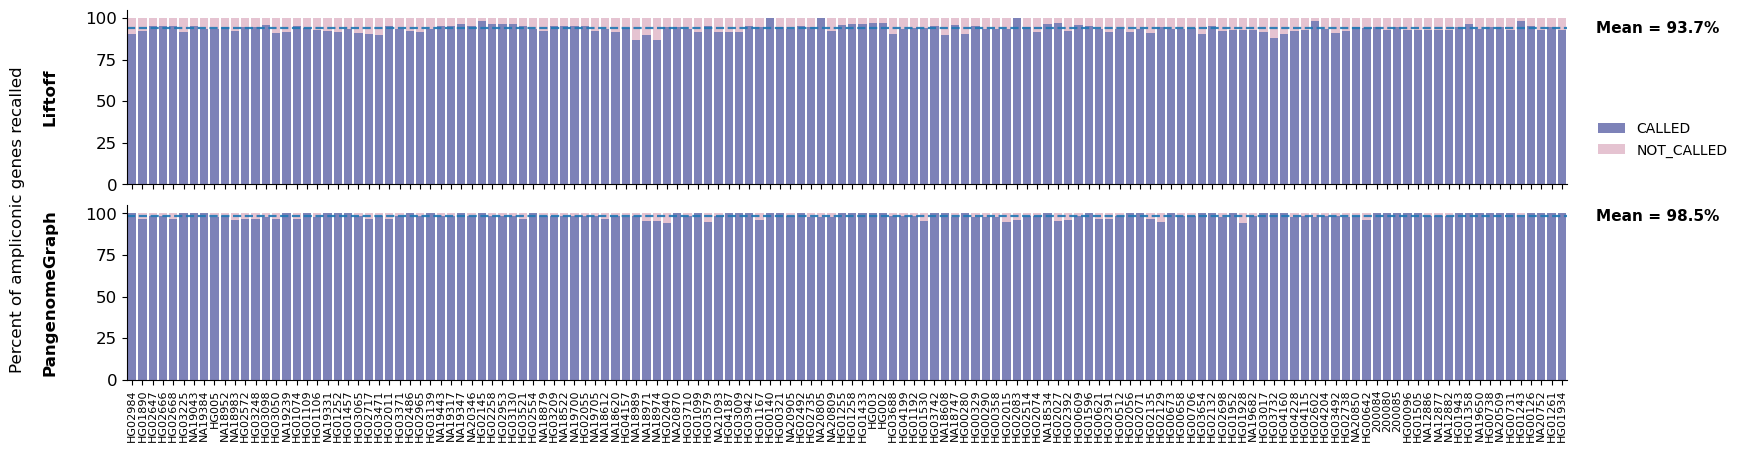

In [46]:
from __future__ import annotations

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt


def amplicon_dict_to_call_df(
    ampliconDict: dict,
    phylogeneticOrder: tuple | list,
    callers: tuple = ("Liftoff", "PangenomeGraph"),
    *,
    called_key: str = "CALLED",
    not_called_key: str = "NOT_CALLED",
) -> pd.DataFrame:
    """
    Build a long/tidy dataframe of called/not-called counts and percentages per sample and caller.
    """
    rows = []
    for sample in phylogeneticOrder:
        if sample not in ampliconDict:
            continue
        for caller in callers:
            if caller not in ampliconDict[sample]:
                continue

            c = ampliconDict[sample][caller].get("call_counts", {})
            called = int(c.get(called_key, 0))
            not_called = int(c.get(not_called_key, 0))
            total = called + not_called

            if total == 0:
                called_pct = 0.0
                not_called_pct = 0.0
            else:
                called_pct = 100.0 * called / total
                not_called_pct = 100.0 * not_called / total

            rows.append(
                {
                    "Sample": sample,
                    "Caller": caller,
                    "CALLED": called,
                    "NOT_CALLED": not_called,
                    "Total": total,
                    "CALLED_pct": called_pct,
                    "NOT_CALLED_pct": not_called_pct,
                }
            )

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    sample_order = [s for s in phylogeneticOrder if s in set(df["Sample"])]
    df["Sample"] = pd.Categorical(df["Sample"], categories=sample_order, ordered=True)
    df["Caller"] = pd.Categorical(df["Caller"], categories=list(callers), ordered=True)

    df = df.sort_values(["Caller", "Sample"]).reset_index(drop=True)
    return df


def plot_called_notcalled_stacked(
    df_calls,
    phylogeneticOrder,
    callers=("Liftoff", "PangenomeGraph"),
    *,
    figsize=(30, 8),
    rotate_xticks=90,
    fontsize_base=14,
    tick_fontsize=8,
    title_fontsize=14,
    label_fontsize=12,
    legend_fontsize=10,
    median_fontsize=11,
    output_png=None,
    output_pdf=None,
    dpi=300,
):

    import matplotlib as mpl
    import matplotlib.pyplot as plt

    if df_calls is None or df_calls.empty:
        raise ValueError("df_calls is empty — nothing to plot.")

    mpl.rcParams["font.size"] = fontsize_base
    mpl.rcParams["axes.titlesize"] = title_fontsize
    mpl.rcParams["axes.labelsize"] = label_fontsize
    mpl.rcParams["xtick.labelsize"] = tick_fontsize
    mpl.rcParams["ytick.labelsize"] = label_fontsize
    mpl.rcParams["legend.fontsize"] = legend_fontsize

    sample_order = [
        s for s in phylogeneticOrder
        if s in set(df_calls["Sample"].astype(str))
    ]

    fig, axes = plt.subplots(
        nrows=len(callers),
        ncols=1,
        figsize=figsize,
        sharex=True,
        constrained_layout=False,
    )

    if len(callers) == 1:
        axes = [axes]

    CALLED_COLOR = "#7D82B8"
    NOT_CALLED_COLOR = "#E5C3D1"

    for ax, caller in zip(axes, callers):

        sub = df_calls[df_calls["Caller"] == caller].copy()
        sub = sub.set_index("Sample").reindex(sample_order)

        sub["CALLED_pct"] = sub["CALLED_pct"].fillna(0.0)
        sub["NOT_CALLED_pct"] = sub["NOT_CALLED_pct"].fillna(0.0)

        x = list(range(len(sample_order)))

        ax.bar(x, sub["CALLED_pct"], color=CALLED_COLOR, label="CALLED")
        ax.bar(
            x,
            sub["NOT_CALLED_pct"],
            bottom=sub["CALLED_pct"],
            color=NOT_CALLED_COLOR,
            label="NOT_CALLED",
        )

        ax.set_ylim(0, 105)
        ax.set_ylabel(caller, fontweight="bold", labelpad=20)

        median_called = float(sub["CALLED_pct"].mean())

        ax.axhline(
            median_called,
            linestyle="--",
            linewidth=1.6,
            alpha=0.9,
        )

        ax.text(
            1.02,  
            median_called,
            f"Mean = {median_called:.1f}%",
            transform=ax.get_yaxis_transform(), 
            ha="left",
            va="center",
            fontsize=median_fontsize,
            fontweight="bold",
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.text(
        0.015,
        0.5,
        "Percent of ampliconic genes recalled",
        va="center",
        rotation="vertical",
        fontsize=label_fontsize,
    )

    axes[-1].set_xticks(range(len(sample_order)))
    axes[-1].set_xticklabels(sample_order, rotation=rotate_xticks, ha="center")

    n = len(sample_order)
    axes[-1].set_xlim(-0.5, n - 0.5)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.subplots_adjust(
        left=0.08,
        right=0.88,   
        top=0.92,
        bottom=0.18,  
        hspace=0.12,
    )
    fig.legend(
        handles,
        labels,
        loc="upper left",
        bbox_to_anchor=(0.89, 0.72),
        frameon=False,
    )

    if output_png:
        fig.savefig(output_png, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    if output_pdf:
        fig.savefig(output_pdf, bbox_inches="tight", pad_inches=0.02)

    plt.show()

    
df_calls = amplicon_dict_to_call_df(
    ampliconDict=ampliconDict,
    phylogeneticOrder=phylogeneticOrder,
    callers=("Liftoff", "PangenomeGraph"),
)

plot_called_notcalled_stacked(
    df_calls,
    phylogeneticOrder=phylogeneticOrder,
    callers=("Liftoff", "PangenomeGraph"),
    figsize=(18, 5),
    rotate_xticks=90,
    output_png="/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/Ampliconic_Recall.03102026.jpeg",
    output_pdf="/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/Ampliconic_Recall.03102026.pdf",
)

In [34]:
testDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/CombinedFiles/HG03579_combinedAnnotation.03102026.csv")

In [35]:
Feyzadf = pd.read_csv(os.path.join(directory, 'HG01934_chrY.fa.gff'), sep='\t', comment='#', header=None)
df = Feyzadf[(Feyzadf[2]=='gene')].copy()
df['GeneID'] = [x.split(';')[0].split("=")[1] for x in df[8]]
df['GeneName'] = [x.split('gene_name=')[1].split(";")[0] for x in df[8]]
df['GeneBiotype'] = [x.split('gene_biotype=')[1].split(";")[0] for x in df[8]]
df["coverage"] = [float(x.split('coverage=')[1].split(";")[0]) for x in df[8]]
df["sequence_ID"] = [float(x.split('sequence_ID=')[1].split(";")[0]) for x in df[8]]
df1 = df[(df['coverage'] >= .95) & (df['sequence_ID'] >= .95)].copy()

In [36]:
sampleName='HG01934'
prajnaDF = pd.read_csv(prajnadirectory+sampleName+"_chrY_consensus.gff3", sep='\t', comment='#', header=None)
df2 = prajnaDF[(prajnaDF[2] == 'gene')].copy()

gene_id   = df2[8].str.extract(r'ID=([^;]+)', expand=False)
gene_name = df2[8].str.extract(r'gene_name=([^;]+)', expand=False)
name_attr = df2[8].str.extract(r'Name=([^;]+)', expand=False)

df2["GeneName"]   = gene_name.fillna(name_attr).fillna(name_attr).astype(str)
df2["GeneName2"]  = name_attr
df2["Orig_GeneBiotype"] = df2[8].str.extract(r'gene_biotype=([^;]+)', expand=False)

changeBioDict={'lncRNA':'lncRNA',
             'miRNA':'miRNA',
             'misc_RNA':'misc_RNA',
             'processed_pseudogene':'pseudogene',
             'protein_coding':'protein_coding',
             'rRNA_pseudogene':'pseudogene',
             'snRNA':'snRNA',
             'snoRNA':'snoRNA',
             'transcribed_processed_pseudogene':'transcribed_pseudogene',
             'transcribed_unitary_pseudogene':'transcribed_pseudogene',
             'transcribed_unprocessed_pseudogene':'transcribed_pseudogene',
             'unprocessed_pseudogene':'pseudogene'
            }
df2["GeneBiotype"]=[changeBioDict[x] for x in df2["Orig_GeneBiotype"]]

In [37]:
np.median(df_calls[df_calls['Caller']=='Liftoff']['CALLED_pct'])

np.float64(93.61702127659575)

In [38]:
np.mean(df_calls[df_calls['Caller']=='Liftoff']['CALLED_pct'])

np.float64(93.68403425013254)

In [39]:
np.median(df_calls[df_calls['Caller']=='PangenomeGraph']['CALLED_pct'])

np.float64(98.38709677419355)

In [40]:
np.mean(df_calls[df_calls['Caller']=='PangenomeGraph']['CALLED_pct'])

np.float64(98.52456747204282)

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_top_missed_genes_shared_cbar(
    gene_df: pd.DataFrame,
    phylogeneticOrder: tuple | list,
    callers: tuple = ("Liftoff", "PangenomeGraph"),
    *,
    top_n_genes: int = 25,
    figsize=(18, 10),
    output_png: str | None = None,
    output_pdf: str | None = None,
    dpi: int = 300,
):
    if gene_df is None or gene_df.empty:
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.text(0.5, 0.5, "No missed gene counts available", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        plt.show()
        return

    sample_order = [s for s in phylogeneticOrder if s in set(gene_df["Sample"].astype(str))]

    top_genes = (
        gene_df.groupby("Gene")["Count"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n_genes)
        .index
        .tolist()
    )

    fig, axes = plt.subplots(nrows=len(callers), ncols=1, figsize=figsize, sharex=True)
    if len(callers) == 1:
        axes = [axes]

    mats = {}
    for caller in callers:
        sub = gene_df[(gene_df["Caller"] == caller) & (gene_df["Gene"].isin(top_genes))].copy()
        piv = sub.pivot_table(index="Gene", columns="Sample", values="Count", aggfunc="sum", fill_value=0)
        piv = piv.reindex(index=top_genes, fill_value=0)
        piv = piv.reindex(columns=sample_order, fill_value=0)
        mats[caller] = piv.values

    global_max = max(int(np.max(m)) for m in mats.values()) if mats else 0
    vmin, vmax = 0, (global_max if global_max > 0 else 1)

    im_last = None
    for ax, caller in zip(axes, callers):
        mat = mats[caller]
        im = ax.imshow(mat, aspect="auto", vmin=vmin, vmax=vmax)
        im_last = im

        ax.set_title(f"{caller}: missed ampliconic genes (counts)", pad=6)
        ax.set_ylabel("Gene")

        ax.set_yticks(np.arange(len(top_genes)))
        ax.set_yticklabels(top_genes)

        if ax is not axes[-1]:
            ax.set_xticks([])
        else:
            ax.set_xticks(np.arange(len(sample_order)))
            ax.set_xticklabels(sample_order, rotation=90, ha="center", va="top")

    fig.subplots_adjust(left=0.18, right=0.90, top=0.92, bottom=0.25, hspace=0.25)
    cax = fig.add_axes([0.92, 0.25, 0.015, 0.67])
    cbar = fig.colorbar(im_last, cax=cax)
    cbar.set_label("Missed gene count")

    if output_png:
        fig.savefig(output_png, dpi=dpi, bbox_inches="tight", pad_inches=0.08)
    if output_pdf:
        fig.savefig(output_pdf, bbox_inches="tight", pad_inches=0.08)

    plt.show()


In [42]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def amplicon_dict_to_missed_detail_dfs(
    ampliconDict: dict,
    phylogeneticOrder: tuple | list,
    callers: tuple = ("Liftoff", "PangenomeGraph"),
):
    """
    Returns:
      seqclass_df: columns = Sample, Caller, Seqclass, Count
      gene_df:     columns = Sample, Caller, Gene, Count
    """
    seq_rows = []
    gene_rows = []

    for sample in phylogeneticOrder:
        if sample not in ampliconDict:
            continue
        for caller in callers:
            if caller not in ampliconDict[sample]:
                continue

            seq_counter = ampliconDict[sample][caller].get("seqClass_counts", {})
            gene_counter = ampliconDict[sample][caller].get("gene_counts", {})

            for k, v in getattr(seq_counter, "items", lambda: [])():
                seq_rows.append({"Sample": sample, "Caller": caller, "Seqclass": str(k), "Count": int(v)})

            for k, v in getattr(gene_counter, "items", lambda: [])():
                gene_rows.append({"Sample": sample, "Caller": caller, "Gene": str(k), "Count": int(v)})

    seqclass_df = pd.DataFrame(seq_rows)
    gene_df = pd.DataFrame(gene_rows)

    # enforce ordering
    sample_order = [s for s in phylogeneticOrder if s in set(ampliconDict.keys())]
    for df, col in [(seqclass_df, "Sample"), (gene_df, "Sample")]:
        if not df.empty:
            df[col] = pd.Categorical(df[col], categories=sample_order, ordered=True)
            df["Caller"] = pd.Categorical(df["Caller"], categories=list(callers), ordered=True)
            df.sort_values(["Caller", col], inplace=True)

    return seqclass_df, gene_df


def plot_missed_seqclass_stacked_percent(
    seqclass_df: pd.DataFrame,
    phylogeneticOrder: tuple | list,
    callers: tuple = ("Liftoff", "PangenomeGraph"),
    *,
    figsize=(35, 10),
    rotate_xticks=90,
    top_k_classes: int = 6,
    other_label: str = "OTHER",
    output_png: str | None = None,
    output_pdf: str | None = None,
    dpi: int = 300,
):
    """
    Two-panel stacked bar plot of the composition of MISSED calls (percent),
    broken down by Seqclass (top K + OTHER).
    """
    sample_order = [s for s in phylogeneticOrder if s in set(seqclass_df["Sample"].astype(str))] if not seqclass_df.empty else list(phylogeneticOrder)

    fig, axes = plt.subplots(nrows=len(callers), ncols=1, figsize=figsize, sharex=True)
    if len(callers) == 1:
        axes = [axes]

    if seqclass_df.empty:
        for ax, caller in zip(axes, callers):
            ax.set_title(caller)
            ax.text(0.5, 0.5, "No missed seqclass counts available", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
        plt.show()
        return

    top_classes = (
        seqclass_df.groupby("Seqclass")["Count"].sum().sort_values(ascending=False).head(top_k_classes).index.tolist()
    )

    for ax, caller in zip(axes, callers):
        sub = seqclass_df[seqclass_df["Caller"] == caller].copy()

        piv = sub.pivot_table(index="Sample", columns="Seqclass", values="Count", aggfunc="sum", fill_value=0)
        piv = piv.reindex(sample_order, fill_value=0)

        for c in list(piv.columns):
            if c not in top_classes:
                piv[other_label] = piv.get(other_label, 0) + piv[c]
                piv.drop(columns=[c], inplace=True)

        cols = [c for c in top_classes if c in piv.columns]
        if other_label in piv.columns:
            cols.append(other_label)
        piv = piv[cols]

        row_sums = piv.sum(axis=1).replace(0, np.nan)
        pct = piv.div(row_sums, axis=0) * 100.0
        pct = pct.fillna(0.0)

        x = np.arange(len(sample_order))
        bottom = np.zeros(len(sample_order))

        for cls in pct.columns:
            ax.bar(x, pct[cls].values, bottom=bottom, label=cls)
            bottom += pct[cls].values

        ax.set_ylabel("Percent of missed")
        ax.set_title(caller, pad=6)
        ax.set_ylim(0, 105)
        ax.grid(axis="y", alpha=0.25)

    axes[-1].set_xticks(np.arange(len(sample_order)))
    axes[-1].set_xticklabels(sample_order, rotation=rotate_xticks, ha="center", va="top")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.subplots_adjust(left=0.06, right=0.83, top=0.92, bottom=0.22, hspace=0.18)
    fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.835, 0.92), frameon=False, title="Missed Seqclass")

    if output_png:
        fig.savefig(output_png, dpi=dpi, bbox_inches="tight", pad_inches=0.08)
    if output_pdf:
        fig.savefig(output_pdf, bbox_inches="tight", pad_inches=0.08)

    plt.show()


def plot_top_missed_genes(
    gene_df: pd.DataFrame,
    phylogeneticOrder: tuple | list,
    callers: tuple = ("Liftoff", "PangenomeGraph"),
    *,
    top_n_genes: int = 25,
    figsize=(18, 10),
    output_png: str | None = None,
    output_pdf: str | None = None,
    dpi: int = 300,
):
    """
    Heatmap-style plot of top N missed genes (by total misses) across samples.
    """
    if gene_df.empty:
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.text(0.5, 0.5, "No missed gene counts available", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        plt.show()
        return

    sample_order = [s for s in phylogeneticOrder if s in set(gene_df["Sample"].astype(str))]

    top_genes = gene_df.groupby("Gene")["Count"].sum().sort_values(ascending=False).head(top_n_genes).index.tolist()

    fig, axes = plt.subplots(nrows=len(callers), ncols=1, figsize=figsize, sharex=True)
    if len(callers) == 1:
        axes = [axes]

    for ax, caller in zip(axes, callers):
        sub = gene_df[(gene_df["Caller"] == caller) & (gene_df["Gene"].isin(top_genes))].copy()

        piv = sub.pivot_table(index="Gene", columns="Sample", values="Count", aggfunc="sum", fill_value=0)
        piv = piv.reindex(index=top_genes, fill_value=0)
        piv = piv.reindex(columns=sample_order, fill_value=0)

        mat = piv.values

        im = ax.imshow(mat, aspect="auto")  
        ax.set_title(f"{caller}: missed genes (counts)", pad=6)
        ax.set_ylabel("Gene")

        ax.set_yticks(np.arange(len(top_genes)))
        ax.set_yticklabels(top_genes)

        # keep x ticks only on bottom axis
        if ax is not axes[-1]:
            ax.set_xticks([])
        else:
            ax.set_xticks(np.arange(len(sample_order)))
            ax.set_xticklabels(sample_order, rotation=90, ha="center", va="top")
        fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)

    fig.subplots_adjust(left=0.15, right=0.98, top=0.92, bottom=0.25, hspace=0.25)

    if output_png:
        fig.savefig(output_png, dpi=dpi, bbox_inches="tight", pad_inches=0.08)
    if output_pdf:
        fig.savefig(output_pdf, bbox_inches="tight", pad_inches=0.08)

    plt.show()


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_23897/2712767252.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="Gene", columns="Sample", values="Count", aggfunc="sum", fill_value=0)
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_23897/2712767252.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="Gene", columns="Sample", values="Count", aggfunc="sum", fill_value=0)


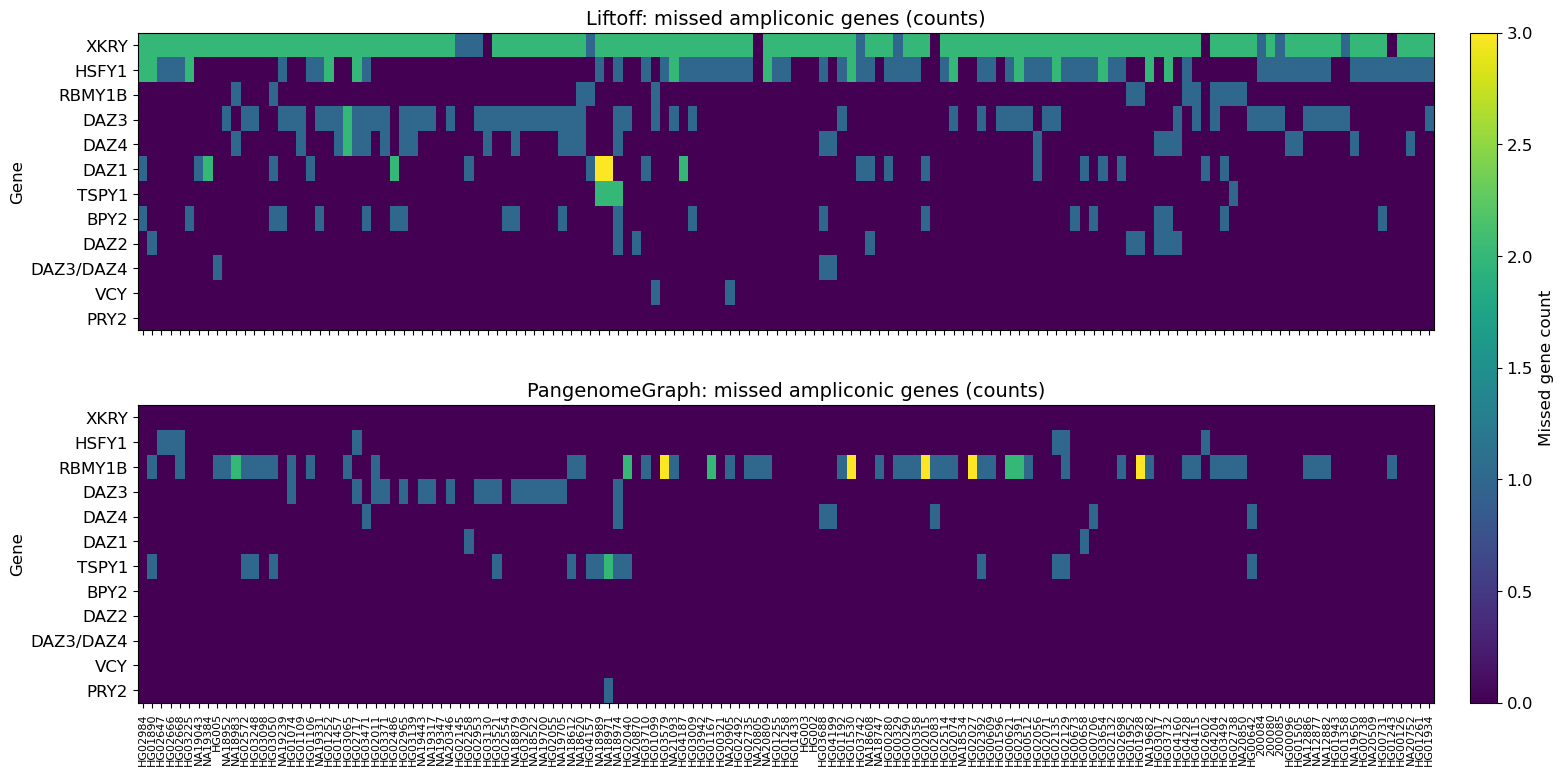

In [45]:
seqclass_df, gene_df = amplicon_dict_to_missed_detail_dfs(
    ampliconDict=ampliconDict,
    phylogeneticOrder=phylogeneticOrder,
    callers=("Liftoff", "PangenomeGraph"),
)

plot_top_missed_genes_shared_cbar(
    gene_df,
    phylogeneticOrder,
    callers=("Liftoff", "PangenomeGraph"),
    top_n_genes=25,
    output_pdf="/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/Top_Missed_Genes_Heatmap_sharedCbar.03102026.pdf",
    output_png="/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/Top_Missed_Genes_Heatmap_sharedCbar.03102026.jpeg"
)